# Détection d'intrusions — Log Authentification
## Projet IDS | Apprentissage supervisé

Shape : (1000, 6)

Infos :
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Log_ID            1000 non-null   int64  
 1   IP_Address        1000 non-null   str    
 2   Request_Type      1000 non-null   str    
 3   Response_Time_ms  1000 non-null   int64  
 4   Anomaly_Score     1000 non-null   float64
 5   Is_Threat         1000 non-null   int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 47.0 KB
None

Valeurs manquantes :
Log_ID              0
IP_Address          0
Request_Type        0
Response_Time_ms    0
Anomaly_Score       0
Is_Threat           0
dtype: int64

Doublons : 0

Distribution cible :
Is_Threat
0    960
1     40
Name: count, dtype: int64


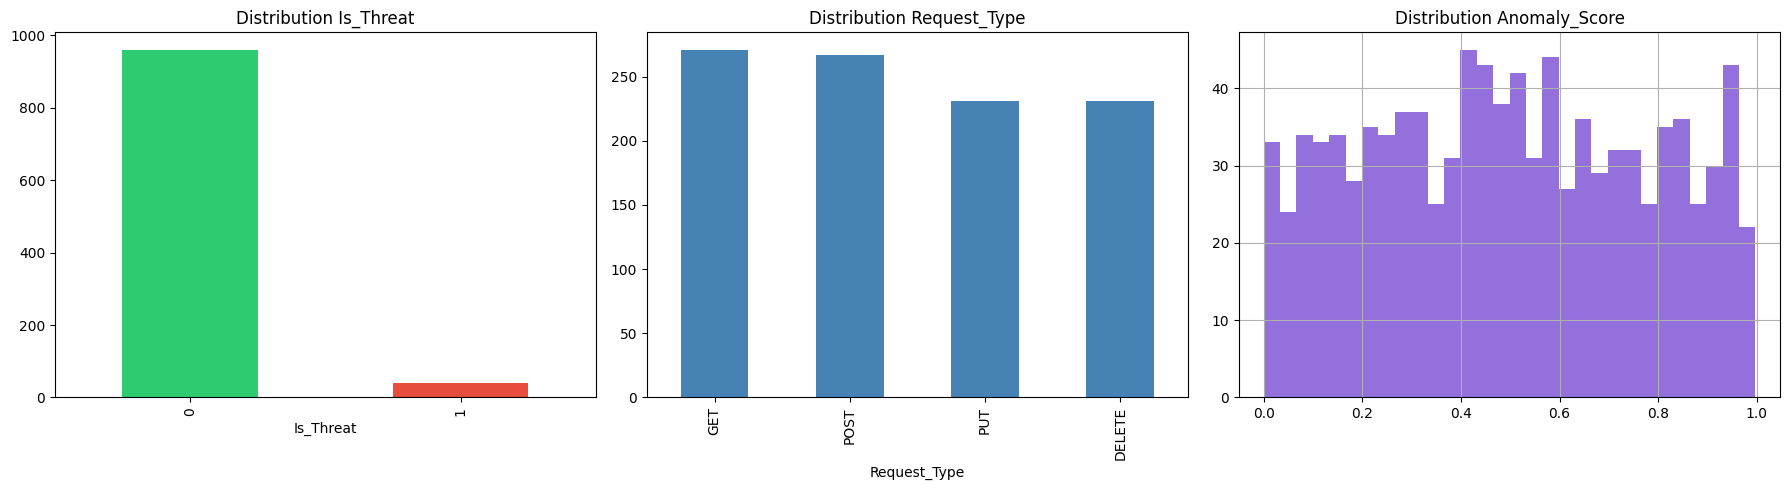

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cybersecurity_logs.csv')
df_meta_auth = df[["IP_Address"]].copy()
print(f"Shape : {df.shape}")
print(f"\nInfos :")
print(df.info())
print(f"\nValeurs manquantes :")
print(df.isnull().sum())
print(f"\nDoublons : {df.duplicated().sum()}")
print(f"\nDistribution cible :")
print(df['Is_Threat'].value_counts())
# Visualisations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['Is_Threat'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'])
axes[0].set_title("Distribution Is_Threat")

df['Request_Type'].value_counts().plot(
    kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title("Distribution Request_Type")

df['Anomaly_Score'].hist(bins=30, ax=axes[2], color='mediumpurple')
axes[2].set_title("Distribution Anomaly_Score")

plt.tight_layout()

plt.show()

## 2. Preprocessing
Extraction des features depuis l'adresse IP, encodage des variables catégorielles,
et création de nouvelles features (is_slow_response, is_high_anomaly).

In [2]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# 1. Supprimer Log_ID
df = df.drop(columns=['Log_ID'])

# 2. Extraire features depuis IP_Address
df['ip_first_octet']  = df['IP_Address'].str.split('.').str[0].astype(int)
df['ip_second_octet'] = df['IP_Address'].str.split('.').str[1].astype(int)
df['ip_third_octet']  = df['IP_Address'].str.split('.').str[2].astype(int)
df['ip_last_octet']   = df['IP_Address'].str.split('.').str[3].astype(int)
df = df.drop(columns=['IP_Address'])

# 3. Encoder Request_Type
mapping_request = {
    'GET'    : 0,
    'POST'   : 1,
    'PUT'    : 2,
    'DELETE' : 3
}
df['Request_Type_encoded'] = df['Request_Type'].map(mapping_request)
df = df.drop(columns=['Request_Type'])

# 4. Feature engineering
df['is_slow_response'] = (df['Response_Time_ms'] > 250).astype(int)
df['is_high_anomaly']  = (df['Anomaly_Score'] > 0.7).astype(int)

print("✅ Features créées :")
print(df.columns.tolist())
display(df.head(5))

✅ Features créées :
['Response_Time_ms', 'Anomaly_Score', 'Is_Threat', 'ip_first_octet', 'ip_second_octet', 'ip_third_octet', 'ip_last_octet', 'Request_Type_encoded', 'is_slow_response', 'is_high_anomaly']


,Response_Time_ms,Anomaly_Score,Is_Threat,ip_first_octet,ip_second_octet,ip_third_octet,ip_last_octet,Request_Type_encoded,is_slow_response,is_high_anomaly
0,216,0.271,0,192,168,251,112,2,0,0
1,280,0.029,0,192,168,92,71,1,1,0
2,223,0.605,0,192,168,164,48,2,0,0
3,265,0.396,0,192,168,51,32,3,1,0
4,171,0.299,0,192,168,21,113,2,0,0


## 3. Modélisation

### 3.1 Random Forest
Modèle principal avec class_weight='balanced' pour gérer le déséquilibre des classes.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
import pickle

# 1. X et y
target_col = 'Is_Threat'
feature_cols = [col for col in df.columns if col != target_col]

X = df[feature_cols]
y = df[target_col]

print(f"Distribution cible :")
print(y.value_counts())

# 2. Split (sans SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Modèle Random Forest (avec class_weight pour déséquilibre)
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # ← gère le déséquilibre
)

model_rf.fit(X_train, y_train)

# 4. Evaluation
y_pred = model_rf.predict(X_test)

print("=" * 50)
print(f"🎯 Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Threat']))

print("✅ Modèle entraîné sans SMOTE")

Distribution cible :
Is_Threat
0    960
1     40
Name: count, dtype: int64
🎯 Accuracy : 96.00%
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98       192
      Threat       0.00      0.00      0.00         8

    accuracy                           0.96       200
   macro avg       0.48      0.50      0.49       200
weighted avg       0.92      0.96      0.94       200

✅ Modèle entraîné sans SMOTE


c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

## 5. Export — output normalisé pour la corrélation

In [4]:
import joblib, os
base = r"C:\Users\asus\Desktop\IDS\models"
os.makedirs(base, exist_ok=True)

joblib.dump(model_rf, base + r"\auth_random_forest.pkl")
print("✅ auth model sauvegardé")

✅ auth model sauvegardé


## 4. Évaluation du modèle

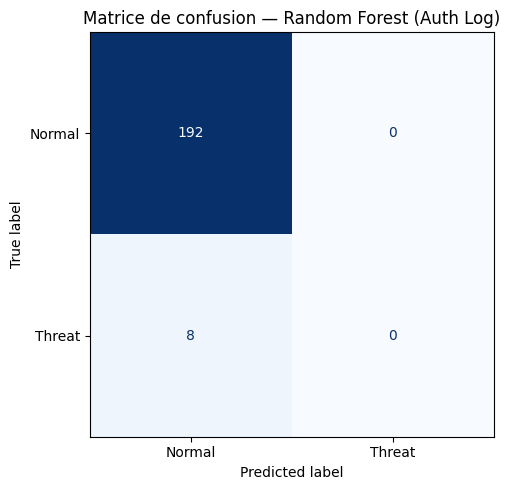

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Threat"]
).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")

ax.set_title("Matrice de confusion — Random Forest (Auth Log)")
plt.tight_layout()
plt.show()

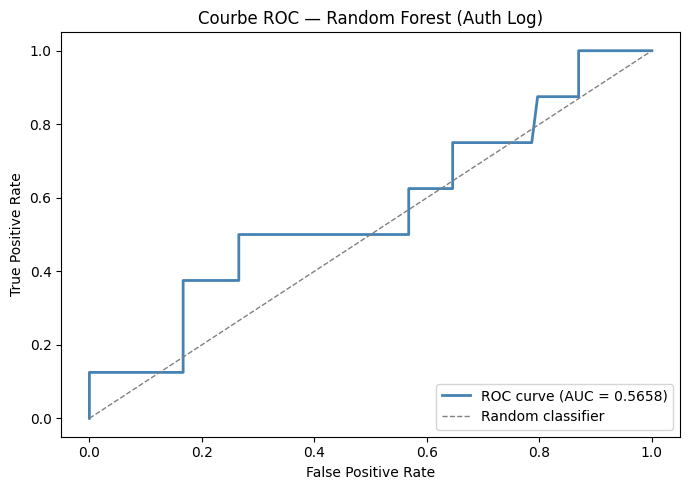

In [6]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_proba = model_rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — Random Forest (Auth Log)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 3.2 XGBoost avec seuil ajusté
Seuil de décision abaissé à 0.3 pour être plus sensible aux menaces rares.

              precision    recall  f1-score   support

      Normal       0.95      0.79      0.86       192
      Threat       0.00      0.00      0.00         8

    accuracy                           0.76       200
   macro avg       0.47      0.39      0.43       200
weighted avg       0.91      0.76      0.83       200



c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:00:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


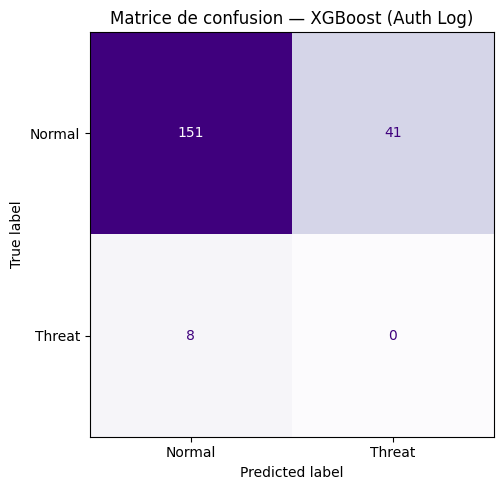

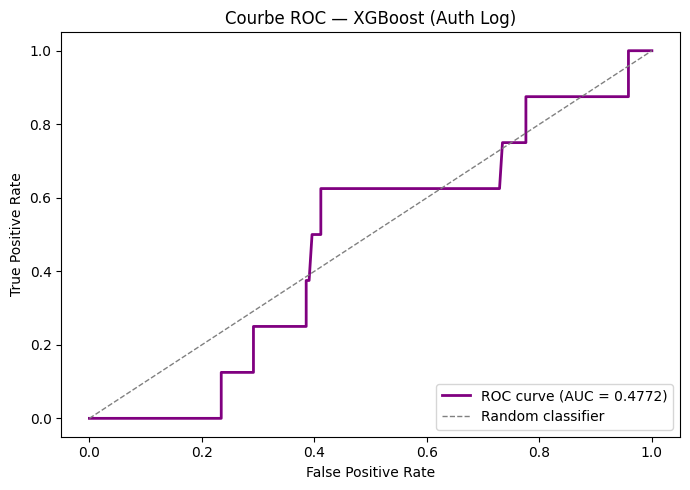

In [7]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ── Features (on supprime les octets IP et is_slow_response) ──
cols_to_drop = ['ip_first_octet', 'ip_second_octet', 
                'ip_third_octet', 'ip_last_octet', 
                'is_slow_response', 'Is_Threat']

X = df.drop(columns=cols_to_drop)
y = df['Is_Threat']

# ── Split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── XGBoost avec scale_pos_weight = 960/40 = 24 ───────────────
model_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=24,   # ← 960/40 corrige le déséquilibre
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

model_xgb.fit(X_train, y_train)

# ── Seuil ajusté à 0.3 (plus sensible aux Threats) ────────────
y_proba = model_xgb.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.3).astype(int)

# ── Résultats ──────────────────────────────────────────────────
print(classification_report(y_test, y_pred, target_names=["Normal", "Threat"]))

# ── Matrice de confusion ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Threat"]
).plot(ax=ax, cmap="Purples", colorbar=False, values_format="d")
ax.set_title("Matrice de confusion — XGBoost (Auth Log)")
plt.tight_layout()
plt.show()

# ── Courbe ROC ─────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — XGBoost (Auth Log)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

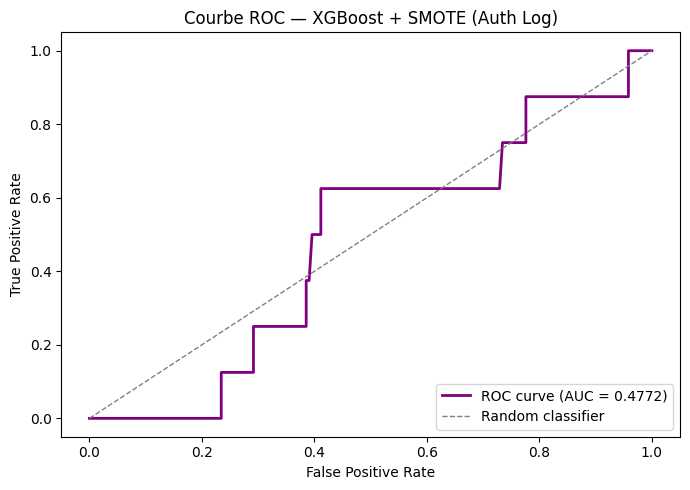

In [8]:
# ── Courbe ROC ────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='purple', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1,
         linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — XGBoost + SMOTE (Auth Log)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd, os
from sklearn.model_selection import train_test_split

base = r"C:\Users\asus\Desktop\IDS\Supervisé\notebooks\outputs"
os.makedirs(base, exist_ok=True)

# Prédire sur TOUT le dataset, pas seulement X_test
# Pour avoir plus de lignes dans l'output
target_col   = 'Is_Threat'
feature_cols = [col for col in df.columns if col != target_col]
X_all = df[feature_cols]

scores_all = model_rf.predict_proba(X_all)[:, 1]

df_auth_normalized = pd.DataFrame({
    "timestamp"     : "unknown",
    "source_ip"     : df_meta_auth.loc[X_all.index, "IP_Address"].values,
    "dest_ip"       : "unknown",
    "log_source"    : "auth",
    "anomaly_score" : scores_all,
    "prediction"    : model_rf.predict(X_all),
    "alert_level"   : ["HIGH"   if s >= 0.7
                       else "MEDIUM" if s >= 0.3
                       else "NORMAL"
                       for s in scores_all],
})

df_auth_normalized.to_csv(
    os.path.join(base, "auth_output_normalized.csv"), index=False
)
print("✅ auth_output_normalized.csv sauvegardé")
print(f"   {len(df_auth_normalized)} lignes")
print(df_auth_normalized.head())

✅ auth_output_normalized.csv sauvegardé
   1000 lignes
  timestamp        source_ip  dest_ip log_source  anomaly_score  prediction  \
0   unknown  192.168.251.112  unknown       auth       0.045861           0   
1   unknown    192.168.92.71  unknown       auth       0.028016           0   
2   unknown   192.168.164.48  unknown       auth       0.204994           0   
3   unknown    192.168.51.32  unknown       auth       0.145186           0   
4   unknown   192.168.21.113  unknown       auth       0.060565           0   

  alert_level  
0      NORMAL  
1      NORMAL  
2      NORMAL  
3      NORMAL  
4      NORMAL  
